In [2]:
import click
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, f1_score
from pointnet_model import pnet
from O16_plotting import plot_events, plot_histogram, plot_zero_one_bins

2024-07-22 15:46:02.378206: I tensorflow/core/util/port.cc:110] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2024-07-22 15:46:03.099682: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2024-07-22 15:46:05.215978: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


2024-07-22 16:06:25.799555: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_0' with dtype double and shape [2527,512,3]
	 [[{{node Placeholder/_0}}]]


79/79 [==============================] - 14s 164ms/step
Mean accuracy: 0.3915741244558765
Number of events: 11638
Number of events in test set: 2527


IndexError: index 3351 is out of bounds for axis 0 with size 27

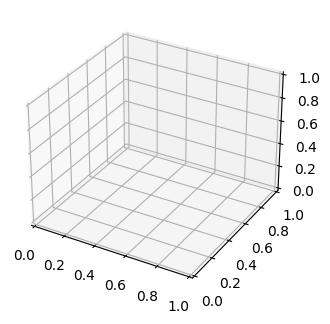

In [7]:
def load_model_and_predict(model_file_stem, data_file_stem, num_points, num_classes):
    model = pnet(sem_seg_flag=True, num_points=num_points, num_classes=num_classes)
    model.load_weights(model_file_stem)

    # Load test data
    BATCH_SIZE = 32
    test_ds = np.load(f'{data_file_stem}test.npy')
    test_features = tf.data.Dataset.from_tensor_slices(test_ds[:, :, :3]).batch(BATCH_SIZE)
    test_labels = test_ds[:, :, 4]

    # Make predictions
    predicted_probabilities = model.predict(test_features)
    predictions = np.argmax(predicted_probabilities, axis=2)

    # Evaluate results
    model_name = model_file_stem.split("/")[-3]
    ckpt_name = model_file_stem.split("/")[-1]
    mean_accuracy = np.mean(test_labels == predictions)
    print(f'Mean accuracy: {mean_accuracy}')  # Point-wise accuracy

    plot_events(test_labels, predictions, data_file_stem, model_name, ckpt_name)
    percent_accuracy = np.mean(test_labels == predictions, axis=1)
    plot_histogram(model_name, percent_accuracy, ckpt_name)
    plot_zero_one_bins(test_labels, predictions, data_file_stem, model_name, ckpt_name)

    # F1 score for evaluation
    f1 = f1_score(test_labels.flatten(), predictions.flatten(), average='weighted')
    print(f'F1 Score: {f1}')

    return mean_accuracy, f1

# Set parameters for the model
num_points = 512  # Default number of points per event
num_classes = 24  # Default number of classes to predict
model_file_stem = 'C16_models/2024-07-22-13:55:28/weights/cp-092.ckpt'  # Example model file stem
data_file_stem = 'C16_downstream/data/C16_size512'  # Example data file stem

# Load model and make predictions
mean_accuracy, f1 = load_model_and_predict(model_file_stem, data_file_stem, num_points, num_classes)